# Bài Tập Thực Hành Trực Quan Hóa Dữ Liệu: COVID-19 tại Đông Nam Á

## Chuẩn bị Dữ liệu (Data Preparation)

Hãy chạy đoạn code sau để tự động lấy dữ liệu từ Our World in Data, lọc các quốc gia Đông Nam Á và xử lý sơ bộ các giá trị thiếu (NaN).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cài đặt style chung cho Seaborn
sns.set_theme(style="whitegrid")

# 1. Tải dữ liệu trực tiếp từ Our World in Data (có thể mất 1-2 phút)
url = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
print("Đang tải dữ liệu...")
df_raw = pd.read_csv(url)

# 2. Lọc dữ liệu khu vực Đông Nam Á & Giới hạn thời gian (2021 - 2022)
asean_countries = ['Vietnam', 'Thailand', 'Indonesia', 'Malaysia', 'Singapore', 'Philippines']
df = df_raw[df_raw['location'].isin(asean_countries)].copy()

df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2022-12-31')]

# 3. Lọc ra các cột quan trọng cần thiết cho bài tập
cols_to_keep = [
    'location', 'date', 'new_cases', 'new_deaths',
    'new_tests', 'total_vaccinations', 'people_fully_vaccinated_per_hundred'
]
df = df[cols_to_keep]

# 4. Xử lý NaN cơ bản (Điền 0 cho ca mắc/tử vong/test mới; fill forward cho vaccine vì là số liệu tích lũy)
df[['new_cases', 'new_deaths', 'new_tests']] = df[['new_cases', 'new_deaths', 'new_tests']].fillna(0)
df['total_vaccinations'] = df.groupby('location')['total_vaccinations'].ffill().fillna(0)
df['people_fully_vaccinated_per_hundred'] = df.groupby('location')['people_fully_vaccinated_per_hundred'].ffill().fillna(0)

print(df.head())

Đang tải dữ liệu...
         location       date  new_cases  new_deaths  new_tests  \
175593  Indonesia 2021-01-01        0.0         0.0        0.0   
175594  Indonesia 2021-01-02        0.0         0.0        0.0   
175595  Indonesia 2021-01-03    51985.0      1497.0        0.0   
175596  Indonesia 2021-01-04        0.0         0.0        0.0   
175597  Indonesia 2021-01-05        0.0         0.0        0.0   

        total_vaccinations  people_fully_vaccinated_per_hundred  
175593                 0.0                                  0.0  
175594                 0.0                                  0.0  
175595                 0.0                                  0.0  
175596                 0.0                                  0.0  
175597                 0.0                                  0.0  


Hãy sử dụng `matplotlib` và `seaborn` để trả lời các câu hỏi bằng biểu đồ. Dữ liệu đang nằm trong biến `df`.

## Câu 1: Phân phối cơ bản (Histogram)
**Bối cảnh:** Trước khi so sánh các nước, ta cần biết quy mô lây nhiễm hàng ngày trong khu vực phân bổ như thế nào.
* **Yêu cầu:** Vẽ **Histogram** cho cột `new_cases`.
* **Hint:** Số ca mắc có ngày bằng 0, có ngày lên tới hàng chục ngàn. Hàm `sns.histplot(bins=50)` sẽ giúp bạn thấy dữ liệu bị lệch (skewed) về bên nào.

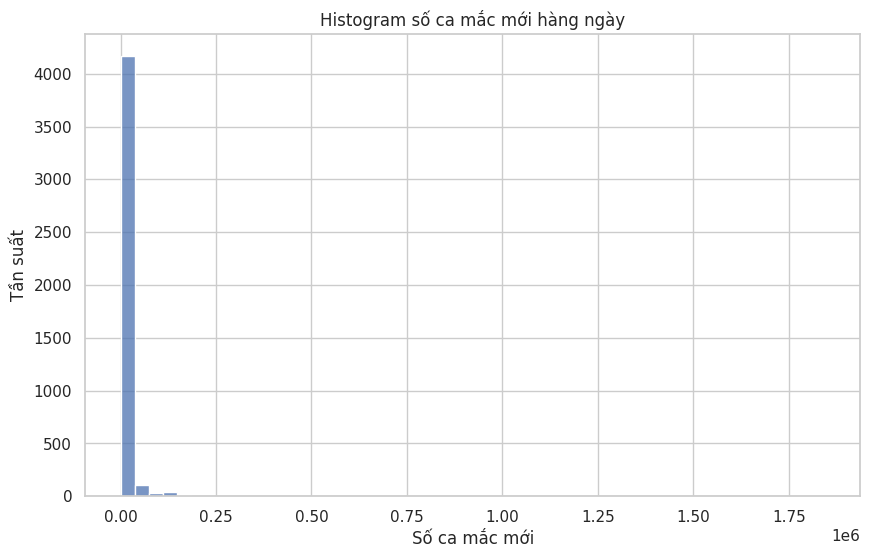

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử dataframe của bạn tên là df
plt.figure(figsize=(10,6))
sns.histplot(df['new_cases'], bins=50, kde=False)

plt.title('Histogram số ca mắc mới hàng ngày')
plt.xlabel('Số ca mắc mới')
plt.ylabel('Tần suất')
plt.show()


## Câu 2: Biến động theo thời gian (Line Chart)
**Bối cảnh:** Biểu đồ ở Câu 1 không cho ta thấy dịch bùng phát *khi nào*. Hãy thêm yếu tố thời gian.
* **Yêu cầu:** Vẽ **Line Chart** thể hiện xu hướng `new_cases` theo `date` của từng quốc gia.
* **Hint:** Sử dụng `sns.lineplot()`. Truyền `x='date'`, `y='new_cases'` và phân loại màu sắc bằng `hue='location'`.

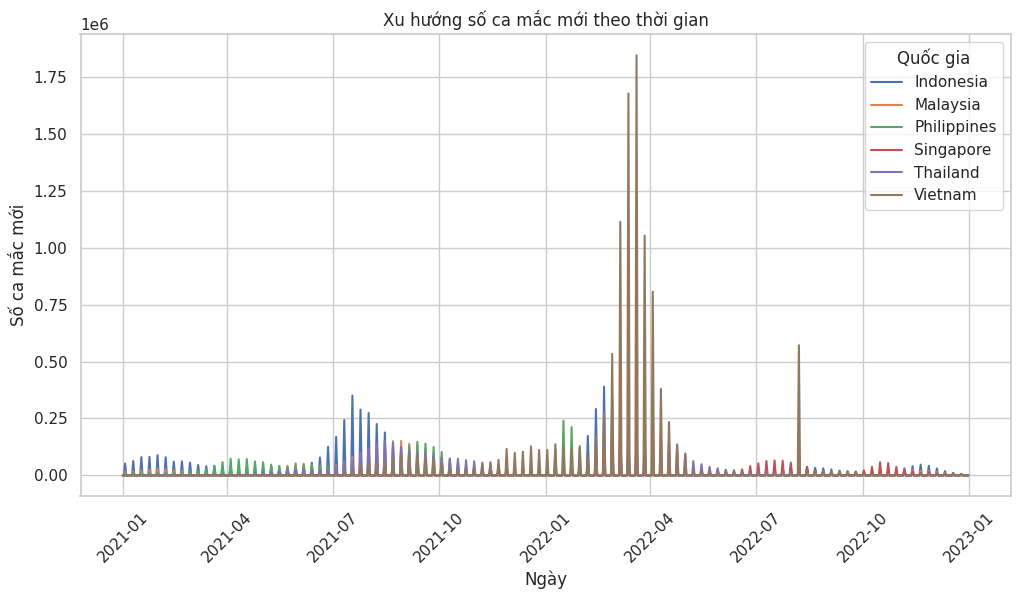

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử dataframe của bạn tên là df
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='date', y='new_cases', hue='location')

plt.title('Xu hướng số ca mắc mới theo thời gian')
plt.xlabel('Ngày')
plt.ylabel('Số ca mắc mới')
plt.legend(title='Quốc gia')
plt.xticks(rotation=45)
plt.show()


## Câu 3: Tổng kết mất mát (Bar Chart)
**Bối cảnh:** Dịch bệnh bùng phát mạnh (Câu 2), vậy tổng thiệt hại về nhân mạng của mỗi quốc gia là bao nhiêu?
* **Yêu cầu:** Dùng **Bar Chart** để vẽ Tổng số ca tử vong (`new_deaths`) của mỗi nước trong giai đoạn này.
* **Hint:** Bạn không thể vẽ trực tiếp từ `df`. Hãy tạo một DataFrame mới bằng cách dùng `.groupby('location')['new_deaths'].sum().reset_index()`, sau đó dùng `sns.barplot()`.

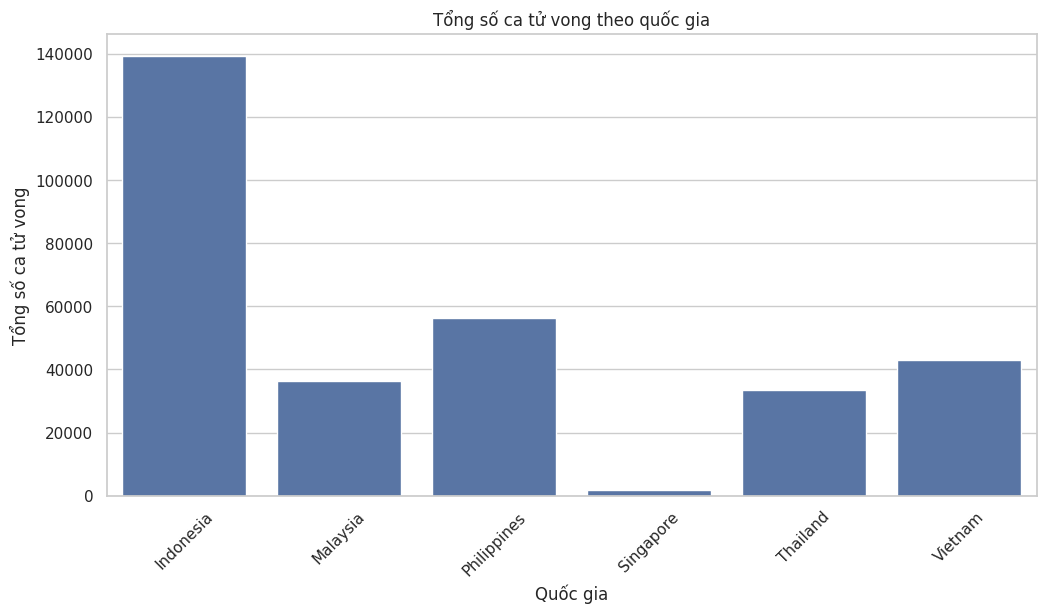

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo DataFrame mới với tổng số ca tử vong theo quốc gia
df_deaths = df.groupby('location')['new_deaths'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=df_deaths, x='location', y='new_deaths')

plt.title('Tổng số ca tử vong theo quốc gia')
plt.xlabel('Quốc gia')
plt.ylabel('Tổng số ca tử vong')
plt.xticks(rotation=45)
plt.show()


## Câu 4: Phân bổ nỗ lực phòng dịch (Pie Chart)
**Bối cảnh:** Để đối phó với số ca tử vong ở Câu 3, các nước bắt đầu chiến dịch tiêm chủng. Nước nào chiếm tỷ trọng số liều vaccine lớn nhất trong nhóm?
* **Yêu cầu:** Vẽ **Pie Chart** thể hiện tỷ trọng tổng số liều vaccine (`total_vaccinations`) đã tiêm của từng nước.
* **Hint (Rất quan trọng):** `total_vaccinations` là *dữ liệu cộng dồn*. Bạn **không được** dùng `.sum()`. Hãy dùng `.groupby('location')['total_vaccinations'].max()` để lấy con số cuối cùng lớn nhất của mỗi nước. Dùng `plt.pie()` để vẽ.

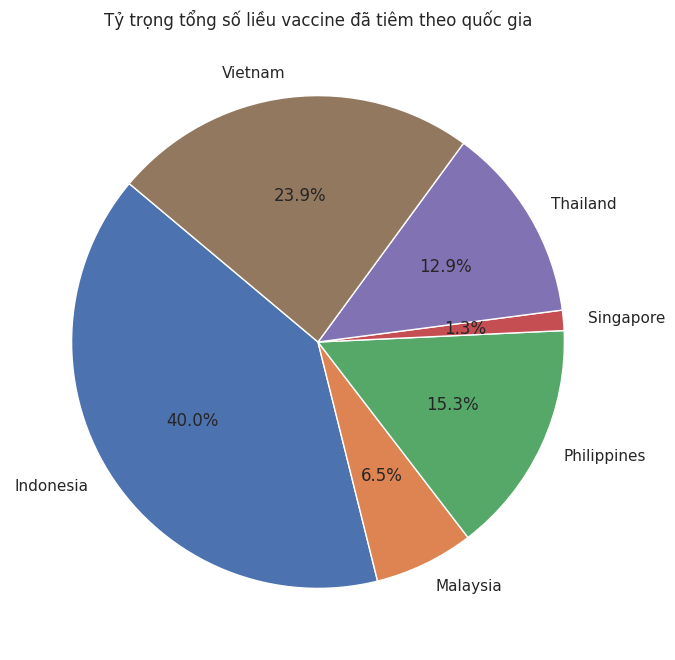

In [6]:
import matplotlib.pyplot as plt

# Tạo DataFrame mới: lấy giá trị cộng dồn lớn nhất (max) của mỗi quốc gia
df_vaccines = df.groupby('location')['total_vaccinations'].max().reset_index()

# Vẽ Pie Chart
plt.figure(figsize=(8,8))
plt.pie(df_vaccines['total_vaccinations'],
        labels=df_vaccines['location'],
        autopct='%1.1f%%',
        startangle=140)

plt.title('Tỷ trọng tổng số liều vaccine đã tiêm theo quốc gia')
plt.show()


## Câu 5: Đo lường sự bất ổn (Box Plot)
**Bối cảnh:** Việc tiêm chủng (Câu 4) bắt đầu làm thay đổi cục diện. Quốc gia nào có số ca mắc mới mỗi ngày biến động khó lường nhất (nhiều outliers nhất)?
* **Yêu cầu:** Vẽ **Box Plot** so sánh sự phân tán của `new_cases` giữa các nước.
* **Hint:** Dùng `sns.boxplot(x='location', y='new_cases')`. Chú ý những điểm chấm đen ngoài râu (whiskers) biểu thị những ngày "đỉnh dịch" (outliers).

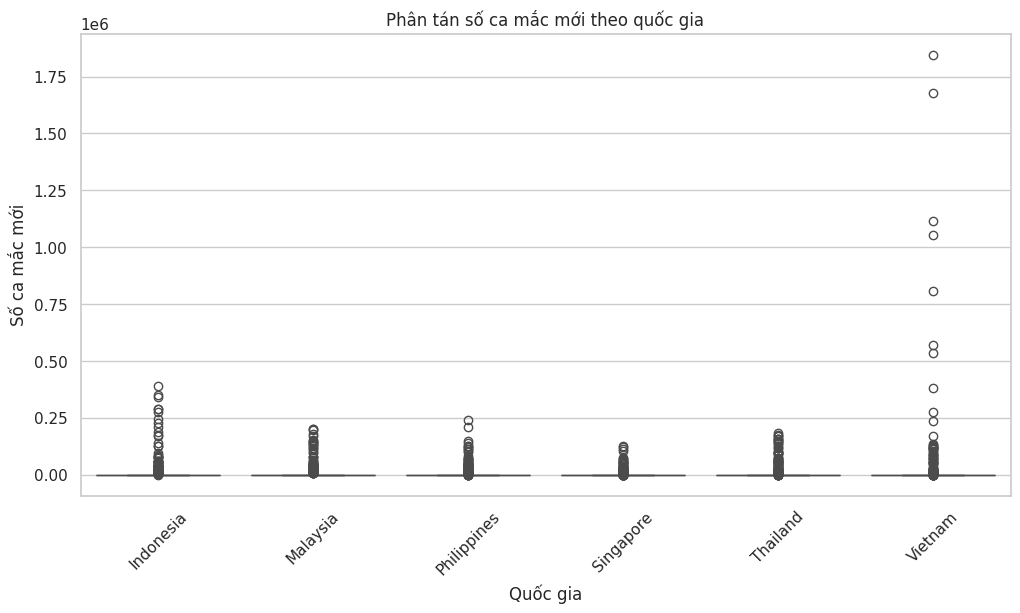

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='location', y='new_cases')

plt.title('Phân tán số ca mắc mới theo quốc gia')
plt.xlabel('Quốc gia')
plt.ylabel('Số ca mắc mới')
plt.xticks(rotation=45)
plt.show()


## Câu 6: Năng lực y tế và lây nhiễm (Scatter Plot)
**Bối cảnh:** Liệu số ca mắc nhiều (Câu 5) có phải chỉ đơn thuần là do nước đó xét nghiệm nhiều?
* **Yêu cầu:** Vẽ **Scatter Plot** để xem xét mối quan hệ giữa số xét nghiệm (`new_tests`) và ca mắc mới (`new_cases`).
* **Hint:** Dùng `sns.scatterplot()`. Vì có rất nhiều ngày số xét nghiệm là 0 (do không báo cáo), bạn có thể lọc các dòng `df['new_tests'] > 0` trước khi vẽ để biểu đồ không bị nhiễu.

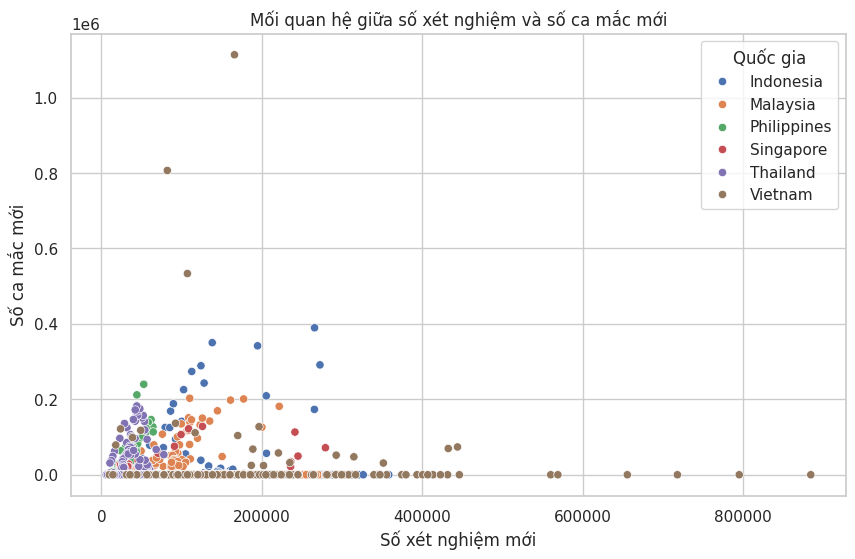

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc bỏ những dòng không có số xét nghiệm (new_tests = 0)
df_filtered = df[df['new_tests'] > 0]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_filtered, x='new_tests', y='new_cases', hue='location')

plt.title('Mối quan hệ giữa số xét nghiệm và số ca mắc mới')
plt.xlabel('Số xét nghiệm mới')
plt.ylabel('Số ca mắc mới')
plt.legend(title='Quốc gia')
plt.show()


## Câu 7: Bức tranh toàn cảnh (Heatmap)
**Bối cảnh:** Đến đây, ta có 4 yếu tố chính: Ca mắc, Ca tử vong, Xét nghiệm, Tỷ lệ tiêm chủng. Chúng tác động qua lại với nhau như thế nào?
* **Yêu cầu:** Vẽ **Heatmap** thể hiện ma trận tương quan giữa 4 cột: `new_cases`, `new_deaths`, `new_tests`, và `people_fully_vaccinated_per_hundred`.
* **Hint:** Lọc ra 4 cột trên, dùng `.corr()` để tạo ma trận toán học, sau đó đưa vào `sns.heatmap(annot=True, cmap='coolwarm')`.

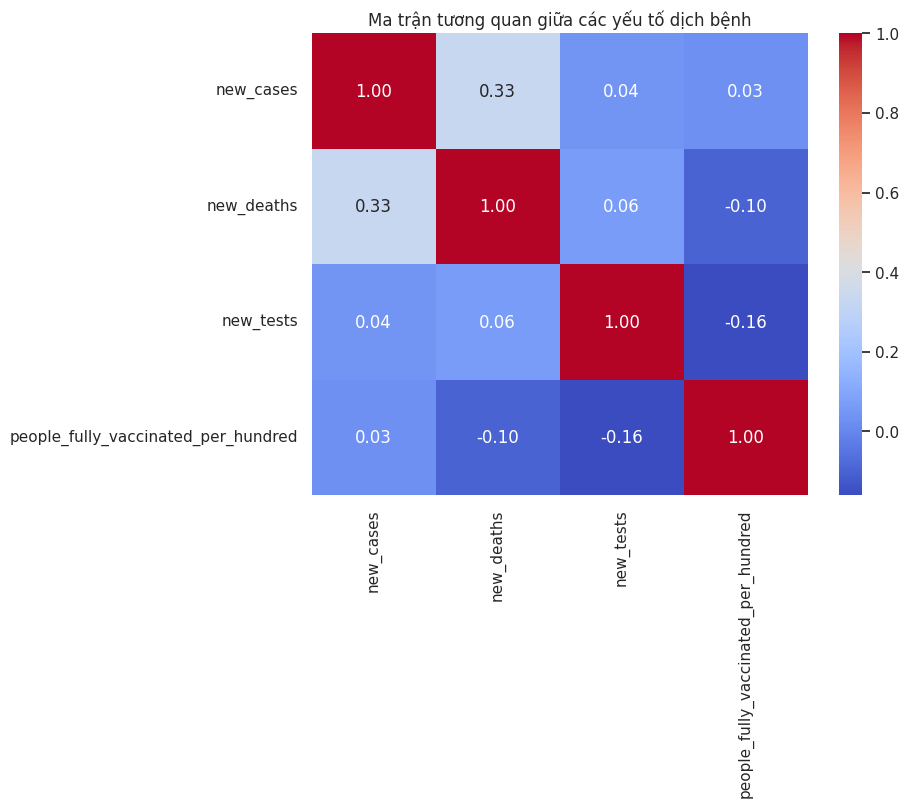

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc ra 4 cột cần thiết
df_corr = df[['new_cases', 'new_deaths', 'new_tests', 'people_fully_vaccinated_per_hundred']]

# Tính ma trận tương quan
corr_matrix = df_corr.corr()

# Vẽ Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Ma trận tương quan giữa các yếu tố dịch bệnh')
plt.show()


## Câu 8: Chứng minh hiệu quả Vắc-xin (Linear Regression Plot)
**Bối cảnh:** Từ Heatmap ở Câu 7, hãy đi sâu vào mối quan hệ quan trọng nhất: Tỷ lệ tiêm chủng cao có thực sự giúp giảm ca tử vong mới không?
* **Yêu cầu:** Vẽ biểu đồ hồi quy **Linear Regression Plot** với trục X là `people_fully_vaccinated_per_hundred` và trục Y là `new_deaths`.
* **Hint:** Dùng `sns.regplot()`. Đường thẳng (trendline) sẽ cho bạn biết xu hướng chung của dữ liệu thực tế.

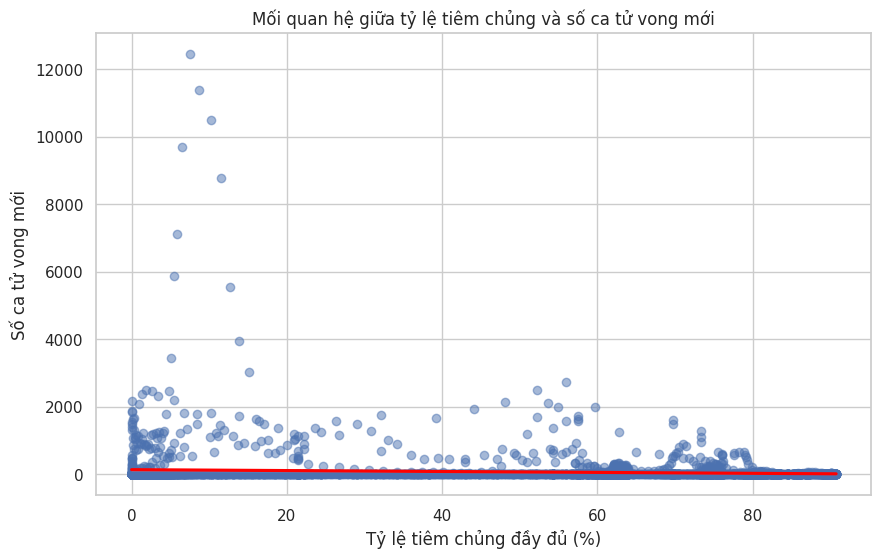

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc dữ liệu cần thiết và loại bỏ giá trị thiếu
df_filtered = df[['people_fully_vaccinated_per_hundred', 'new_deaths']].dropna()

plt.figure(figsize=(10,6))
sns.regplot(data=df_filtered,
            x='people_fully_vaccinated_per_hundred',
            y='new_deaths',
            scatter_kws={'alpha':0.5},  # làm chấm trong suốt để dễ nhìn
            line_kws={'color':'red'})   # đường hồi quy màu đỏ

plt.title('Mối quan hệ giữa tỷ lệ tiêm chủng và số ca tử vong mới')
plt.xlabel('Tỷ lệ tiêm chủng đầy đủ (%)')
plt.ylabel('Số ca tử vong mới')
plt.show()
